<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F04_ray_on_vertex_gpu.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 04 · Autoscaling Ray on Vertex AI: Fractional GPU Packing & Deep Learning Regimes

Run distributed Python and PyTorch deep learning workloads on an ephemeral **Vertex AI Ray cluster** (`engines/ray_engine.py`) connected via Private Service Connect (`PSC-I`).

> [!IMPORTANT]
> **Fractional GPU Packing & Deep Learning Regimes:**
> - **5 Deep Learning Architectures:** `neuralprophet` (AR-Net), `tide`, `tsmixer`, `patchtst`, and `tft` (Temporal Fusion Transformer).
> - **Fractional GPU Allocation (`gpu_fraction = 0.25`):** A single time-series neural network uses only a fraction of an NVIDIA `T4`, `L4`, or `A100` GPU's SMs and VRAM. Packing 4 concurrent Ray tasks per GPU (`@ray.remote(num_gpus=0.25)`) increases GPU throughput up to $4\times$.
> - **Local, Global & Hybrid Regimes:** Every deep learning model supports per-series `local` fits, pooled cross-series `global` fits, and `hybrid` (local `theta` baseline + global deep learning residual fit).

```mermaid
flowchart LR
    subgraph Cluster["Vertex AI Ray Cluster (PSC-I Ephemeral Lifecycle)"]
        HEAD["Ray Head Node (CPU)"]
        CPU["CPU Worker Pool<br/>statistical · ml"]
        GPU["GPU Worker Pool (T4 · L4 · A100)<br/>deep_learning (num_gpus = 0.25)"]
    end
    subgraph Regimes["Deep Learning Training Regimes"]
        R1["local: 1 network per series"]
        R2["global: 1 pooled network across all series"]
        R3["hybrid: local theta + global DL on residuals"]
    end
    HEAD --> CPU & GPU --> R1 & R2 & R3
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Configure Ray GPU Execution & Explain the Plan

We configure a multi-family run routing `deep_learning` (`neuralprophet`) to a Ray GPU pool (`hardware='gpu'`, `gpu_type='T4'`, `gpu_fraction=0.25`) alongside `native` BigQuery SQL models (`arima_plus`, `timesfm`), with `model_params={'neuralprophet': {'training_mode': 'global'}}` so the neural network learns shared cross-series temporal representations.

In [3]:
import time
from scale_forecasting import Forecaster, RunConfig

# === Parameters — edit me ===============================================
RUN_NAME = f"nb04 ray gpu {int(time.time())}"
SOURCE_TABLE = "source_series_iceberg"
MODELS = ["neuralprophet", "arima_plus", "timesfm"]
TRAINING_MODE = "global"  # "local" | "global" | "hybrid"
GPU_TYPE = "T4"           # "T4" | "L4" | "A100" | "A100_80GB"
HORIZON = 28
SERIES_LIMIT = 10
N_FOLDS = 2
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    python_runtime="ray",
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=MODELS,
    model_params={"neuralprophet": {"training_mode": TRAINING_MODE}},
    compute={
        "use_gpu": True,
        "gpu_type": GPU_TYPE,
        "gpu_fraction": 0.25,
        "families": {
            "deep_learning": {
                "runtime": "ray",
                "hardware": "gpu",
                "gpu_type": GPU_TYPE,
            }
        },
    },
    features={"holidays": ["US"]},
    backtest={"enabled": True, "n_folds": N_FOLDS, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ["mean", "inverse_error"]},
)

forecaster = Forecaster(cfg, settings=settings)
print("run_id:", forecaster.run_id)
display(forecaster.explain())

run_id: nb04-ray-gpu-1791144910-a006aec1bbcf


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb04-ray-gpu-1791144910-a006aec1bbcf,deep_learning,sf-nb04-ray-gpu-1791144910-a006aec1bbcf-deep_l...,ray,None,NaN,gpu,T4,neuralprophet,neuralprophet:global,10,2,10,none,
1,nb04-ray-gpu-1791144910-a006aec1bbcf,native,sf-nb04-ray-gpu-1791144910-a006aec1bbcf-native-a1,bigquery,sql,1.0,sql,None,"arima_plus, timesfm","arima_plus:local, timesfm:local",10,2,20,none,
2,nb04-ray-gpu-1791144910-a006aec1bbcf,ensemble,sf-nb04-ray-gpu-1791144910-a006aec1bbcf-ensemb...,bigquery,sql,1.0,sql,None,"ensemble_mean, ensemble_inverse_error",barrier,10,2,20,none,sf-nb04-ray-gpu-1791144910-a006aec1bbcf-deep_l...


## Act 3 · Launch & Monitor Live (`forecaster.run_live()`)

The Ray engine provisions an ephemeral Vertex AI Ray cluster with a GPU worker pool, submits the deep learning family job over Private Service Connect, streams results to BigQuery, and **always tears down the cluster in a `finally:` block**.

[Ray on Vertex AI]: Cluster State = 1
Waiting for cluster provisioning; attempt 1; sleeping for 0:02:30 seconds


[Ray on Vertex AI]: Cluster State = 1
Waiting for cluster provisioning; attempt 1; sleeping for 0:02:30 seconds


[Ray on Vertex AI]: Cluster State = 1
Waiting for cluster provisioning; attempt 2; sleeping for 0:01:54.750000 seconds


[Ray on Vertex AI]: Cluster State = 1
Waiting for cluster provisioning; attempt 2; sleeping for 0:01:54.750000 seconds


[Ray on Vertex AI]: Cluster State = 1
Waiting for cluster provisioning; attempt 3; sleeping for 0:01:27.783750 seconds


...

[Ray on Vertex AI]: Cluster State = 3


[Ray on Vertex AI]: Cluster State = 3


[Ray on Vertex AI]: Cluster State = 3


[Ray on Vertex AI]: Successfully deleted the cluster.


Run nb04-ray-gpu-1791144910-a006aec1bbcf finished: status=COMPLETED, runtime=1322.7s


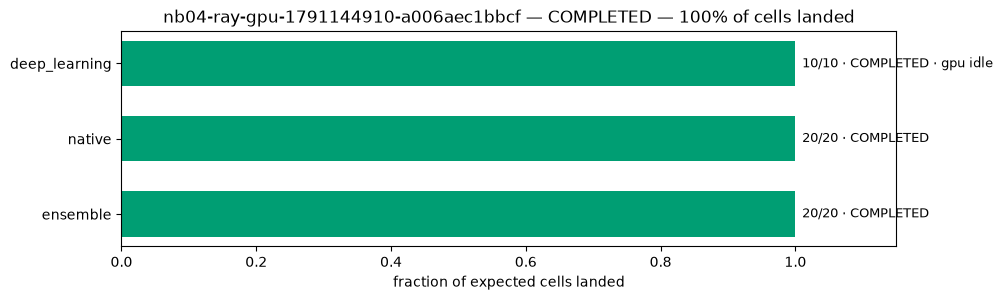

In [4]:
result = forecaster.run_live(poll_s=20.0, probe=True)
print(f"Run {result.run_id} finished: status={result.status}, runtime={result.runtime_seconds:.1f}s")

## Act 4 · Review Leaderboard, Forecast Fan Charts & Cluster Telemetry

Let's inspect the unified leaderboard (`ray` GPU vs. `bigquery` SQL vs. `ensemble`), plot the forecast intervals, and inspect the Ray cluster provisioning vs. execution timeline via `forecaster.trace()`.

,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,arima_plus,native,False,None,bigquery,10,wape,0.384178,0.128754,...,13.203770,17.367465,0.612500,66.270220,NaN,NaN,1.0,280,NaN,NaN
1,2,timesfm,native,False,None,bigquery,10,wape,0.391546,0.126123,...,13.521361,17.803054,0.746429,60.071445,NaN,NaN,1.0,280,NaN,NaN
2,3,ensemble_inverse_error,ensemble,True,55cf2eed0555,ensemble,10,wape,0.399972,0.122570,...,13.062249,16.853214,NaN,NaN,NaN,NaN,1.0,280,-0.015794,-0.041110
3,4,ensemble_mean,ensemble,True,55cf2eed0555,ensemble,10,wape,0.407634,0.133107,...,14.146958,17.858430,NaN,NaN,NaN,NaN,1.0,280,-0.023455,-0.061053
4,5,neuralprophet,deep_learning,False,None,ray,10,wape,0.520993,0.209356,...,21.744568,25.072148,0.667857,108.910523,13.938755,13.938755,1.0,280,NaN,NaN


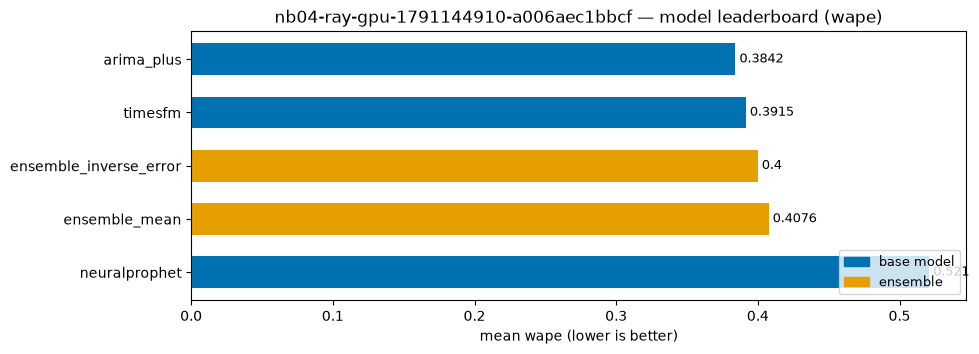

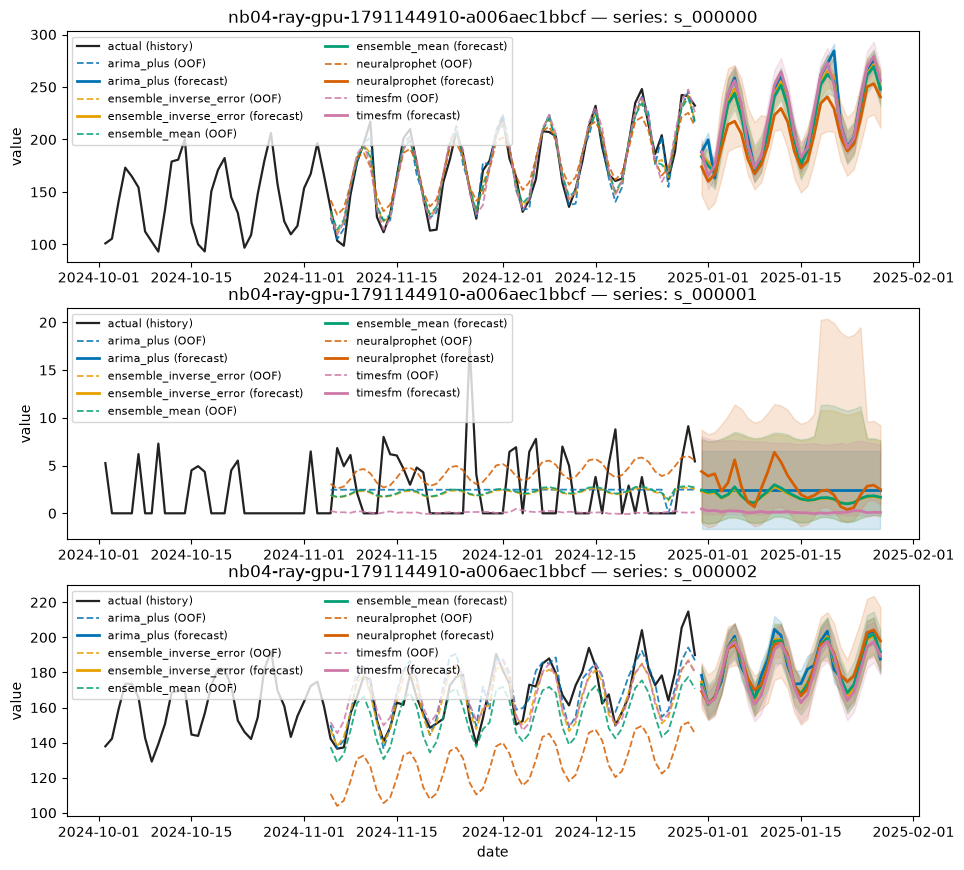

,kind,lane,label,start,end,duration_s,status,runtime,model_type,ts_id
0,job,deep_learning,deep_learning,2026-10-04 20:15:58.586639+00:00,2026-10-04 20:36:42.834042+00:00,1244.247403,COMPLETED,ray,None,None
1,job,ensemble,ensemble,2026-10-04 20:36:48.085152+00:00,2026-10-04 20:37:00.323550+00:00,12.238398,COMPLETED,bigquery,None,None
2,job,native,native,2026-10-04 20:15:58.835594+00:00,2026-10-04 20:17:47.564163+00:00,108.728569,COMPLETED,bigquery,None,None
3,cell,cmle-training-workerpool0-7129af2120-0-xpxv9:613,neuralprophet:s_000000,2026-10-04 20:33:56.137602+00:00,2026-10-04 20:36:20.089409+00:00,143.951807,None,ray,neuralprophet,s_000000
4,cell,cmle-training-workerpool0-7129af2120-0-xpxv9:613,neuralprophet:s_000001,2026-10-04 20:33:56.137602+00:00,2026-10-04 20:36:20.089409+00:00,143.951807,None,ray,neuralprophet,s_000001
5,cell,cmle-training-workerpool0-7129af2120-0-xpxv9:613,neuralprophet:s_000002,2026-10-04 20:33:56.137602+00:00,2026-10-04 20:36:20.089409+00:00,143.951807,None,ray,neuralprophet,s_000002
6,cell,cmle-training-workerpool0-7129af2120-0-xpxv9:613,neuralprophet:s_000003,2026-10-04 20:33:56.137602+00:00,2026-10-04 20:36:20.089409+00:00,143.951807,None,ray,neuralprophet,s_000003
7,cell,cmle-training-workerpool0-7129af2120-0-xpxv9:613,neuralprophet:s_000004,2026-10-04 20:33:56.137602+00:00,2026-10-04 20:36:20.089409+00:00,143.951807,None,ray,neuralprophet,s_000004
8,cell,cmle-training-workerpool0-7129af2120-0-xpxv9:613,neuralprophet:s_000005,2026-10-04 20:33:56.137602+00:00,2026-10-04 20:36:20.089409+00:00,143.951807,None,ray,neuralprophet,s_000005
9,cell,cmle-training-workerpool0-7129af2120-0-xpxv9:613,neuralprophet:s_000006,2026-10-04 20:33:56.137602+00:00,2026-10-04 20:36:20.089409+00:00,143.951807,None,ray,neuralprophet,s_000006


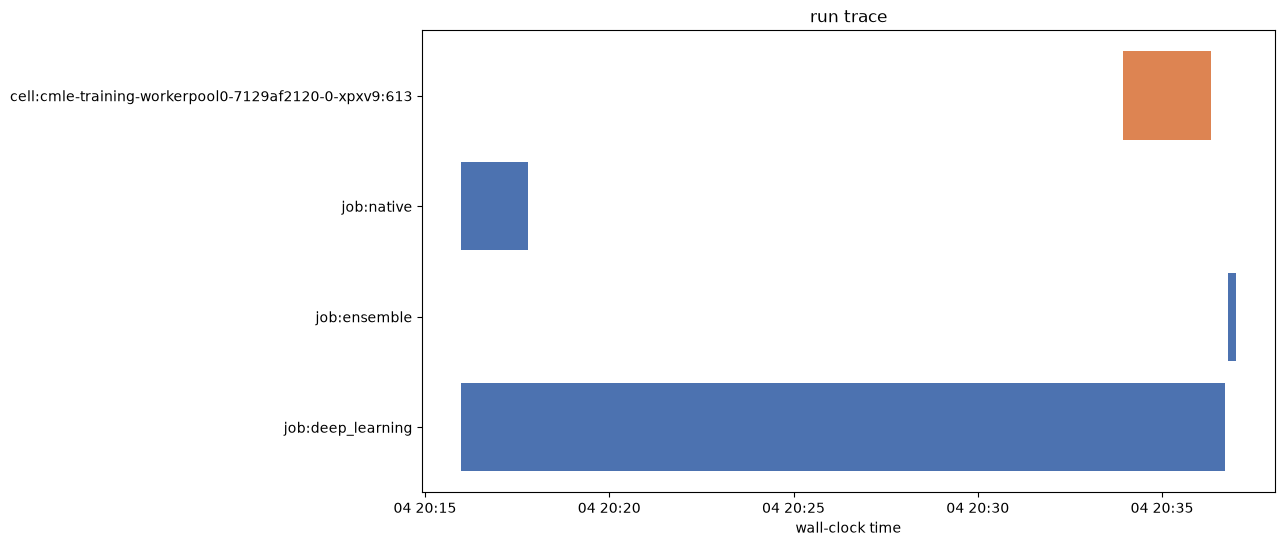

In [5]:
import matplotlib.pyplot as plt
from scale_forecasting import plot_leaderboard, plot_trace

display(forecaster.leaderboard_df())

review = forecaster.review_run()
plot_leaderboard(review)
plt.show()

forecaster.plot_forecasts(history_tail=90)
plt.show()

trace_df = forecaster.trace()
display(trace_df)
plot_trace(trace_df)
plt.show()

## Act 5 · Deep Dive: Direct Ray Engine Embedding (`ray_io.chunk_cells` & `plan_cluster`)

If you manage your own Ray cluster or custom `@ray.remote` actor pipeline, you can use `ray_io.plan_cluster()` and `ray_io.chunk_cells()` to deterministically shard any panel into task-sized pandas chunks and execute them with `run_group()`.

In [6]:
from scale_forecasting.engines.ray_io import chunk_cells, plan_cluster, run_group
from scale_forecasting.playground import sample_data

cluster_plan = plan_cluster(cfg, run_id=forecaster.run_id, use_gpu=True, gpu_type=GPU_TYPE)
print(f"RayClusterPlan: gpu_machine={cluster_plan.gpu_machine_type}, gpu_nodes=[{cluster_plan.gpu_min_nodes}..{cluster_plan.gpu_max_nodes}], fraction={cluster_plan.sizing_gpu_fraction}")

ray_panel = sample_data(n_series=4, history=180, freq="D")
chunks = chunk_cells(ray_panel, cfg, models=["theta"], n_chunks=2)
print(f"Sharded 4 series into {len(chunks)} Ray task chunks: {[c['ts_id'].nunique() for c in chunks]} series per chunk")
chunk_cells_out, chunk_status = run_group(chunks[0], cfg, models=["theta"])
display(chunk_status)

RayClusterPlan: gpu_machine=n1-standard-8, gpu_nodes=[1..2], fraction=0.25


Sharded 4 series into 1 Ray task chunks: [4] series per chunk


,ts_id,model_type,status,fit_seconds
0,s_000000,theta,ok,0.953233
1,s_000001,theta,ok,1.016687
2,s_000002,theta,ok,0.615450
3,s_000003,theta,ok,0.530055
